In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("Đang chuẩn bị dữ liệu để vẽ biểu đồ...")

# 1. LẤY MẪU (SUBSAMPLING) ĐỂ TRÁNH SẬP RAM
# Lấy toàn bộ index của các Lớp vi phạm (1, 2, 3)
threat_idx = y_train[y_train > 0].index

# Lấy ngẫu nhiên 5.000 (hoặc 10.000) dòng Lớp 0 để làm nền
benign_idx = y_train[y_train == 0].sample(n=20000, random_state=42).index

# Gộp lại thành một tập nhỏ để vẽ
sample_idx = threat_idx.tolist() + benign_idx.tolist()
X_sample = X_train.loc[sample_idx]
y_sample = y_train.loc[sample_idx]

# Thuật toán t-SNE/PCA chỉ nhận dữ liệu dạng số (Numeric)
X_sample_numeric = X_sample.select_dtypes(include=[np.number])

# 2. CHUẨN HÓA DỮ LIỆU (BẮT BUỘC TRƯỚC KHI GIẢM CHIỀU)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample_numeric)

# (Tùy chọn) Dùng PCA giảm sơ bộ xuống 50 chiều trước để t-SNE chạy nhanh hơn
pca = PCA(n_components=min(50, X_scaled.shape[1]), random_state=42)
X_pca = pca.fit_transform(X_scaled)

# 3. CHẠY THUẬT TOÁN t-SNE (Giảm xuống 2 chiều)
print("Đang nén dữ liệu bằng t-SNE (Quá trình này có thể mất 1-2 phút)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_pca)

# 4. ĐÓNG GÓI VÀ VẼ BIỂU ĐỒ BẰNG SEABORN
df_plot = pd.DataFrame({
    'TSNE_1': X_tsne[:, 0],
    'TSNE_2': X_tsne[:, 1],
    'Label': y_sample.values
})

# Đổi số thành Tên cho dễ nhìn trên biểu đồ
label_mapping = {0: '0 - Benign', 1: '1 - Scenario 1', 2: '2 - Scenario 2', 3: '3 - Scenario 3'}
df_plot['Label_Name'] = df_plot['Label'].map(label_mapping)

plt.figure(figsize=(12, 8))

# Chọn bảng màu: Lớp 0 màu xám nhạt (để làm nền), 1-2-3 màu rực rỡ để dễ thấy
custom_palette = {'0 - Benign': '#D3D3D3', 
                  '1 - Scenario 1': 'blue', 
                  '2 - Scenario 2': 'orange', 
                  '3 - Scenario 3': 'red'}

sns.scatterplot(
    data=df_plot.sort_values('Label'), # Sort để các Lớp 1,2,3 vẽ sau, nổi lên trên Lớp 0
    x='TSNE_1', 
    y='TSNE_2', 
    hue='Label_Name',
    palette=custom_palette,
    s=60,       # Kích thước chấm
    alpha=0.8,  # Độ trong suốt (0-1)
    edgecolor='w',
    linewidth=0.2
)

plt.title('Biểu đồ t-SNE: Phân tích sự chồng lấn dữ liệu (Data Overlap) giữa các Lớp', fontsize=14, fontweight='bold')
plt.xlabel('Tọa độ t-SNE 1')
plt.ylabel('Tọa độ t-SNE 2')
plt.legend(title='Phân loại', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
#################################################################
# PIPELINE BASELINE: MULTICLASS LIGHTGBM (CHƯA CÂN BẰNG)
#################################################################

import pandas as pd
import numpy as np
import lightgbm as lgb
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
import gc

warnings.filterwarnings('ignore')

print("="*75)
print("🚀 KHỞI ĐỘNG PIPELINE: BASELINE CHƯA CÂN BẰNG (UNBALANCED)")
print("="*75)

# ==============================================================================
# 1️⃣ ĐỌC DỮ LIỆU & LỌC CỘT
# ==============================================================================
file_path = '/kaggle/input/datasets/phanthanhhoang/cert-r42-session/session_r4.2.parquet'
df = pd.read_parquet(file_path)
df['insider'] = df['insider'].astype(int)

# Sort chuẩn theo User và Thời gian
df = df.sort_values(by=['user', 'starttime']).reset_index(drop=True)

# Xác định danh sách feature (Bỏ qua các cột định danh)
exclude_cols = ['insider', 'starttime', 'endtime', 'sessionid', 'user', 'day', 'week',]

drop_cols_leakage = [
    # leakf
    'http_n_leakf',
    'http_leakf_mean_url_len',
    'http_leakf_mean_url_depth',
    'http_leakf_mean_http_c_len',
    'http_leakf_mean_http_c_nwords',

    # hackf
    'http_n_hackf',
    'http_hackf_mean_url_len',
    'http_hackf_mean_url_depth',
    'http_hackf_mean_http_c_len',
    'http_hackf_mean_http_c_nwords',
]
# drop_cols_suspect = [
#     # phof (gần như chỉ class 2)
#     'file_n_phof',
#     'file_phof_mean_file_len',
#     'file_phof_mean_file_nwords',
#     'file_phof_n-disk0',
#     'file_phof_n-disk1',
#     'file_phof_n-disk2',

#     # cloudf (bias class 0 & 2)
#     'http_n_cloudf',
#     'http_cloudf_mean_url_len',
#     'http_cloudf_mean_url_depth',
#     'http_cloudf_mean_http_c_len',
#     'http_cloudf_mean_http_c_nwords',
# ]
# drop_cols_optional = [
#     'file_compf_n-disk1',
#     'file_compf_n-disk2',
#     'file_txtf_n-disk1',
#     'file_txtf_n-disk2',
#     'file_exef_n-disk1',
#     'file_exef_n-disk2',
# ]
feature_cols = [col for col in df.columns if col not in (exclude_cols + drop_cols_leakage)]

#feature_cols = [col for col in df.columns if col not in exclude_cols]

# ==============================================================================
# 2. TIME + USER SPLIT 
# ==============================================================================
def split_user_time_multiclass(df, label_col='insider'):
    print("\n SPLIT USER + TIME")
    # ------------------------------------------------------------------
    # 1. SORT TIME
    # ------------------------------------------------------------------
    df = df.sort_values(by='starttime').reset_index(drop=True)
    n = len(df)
    test_idx = int(n * 0.80)
    df_past = df.iloc[:test_idx].copy()
    df_future = df.iloc[test_idx:].copy()
    print(f"  -> Past: {len(df_past):,} | Future (Test): {len(df_future):,}")
    # ------------------------------------------------------------------
    # 2. LOẠI INSIDER TRONG FUTURE
    # ------------------------------------------------------------------
    known_insiders = set(df_past[df_past[label_col] != 0]['user'])
    df_test = df_future[~df_future['user'].isin(known_insiders)].copy()
    print(f"  -> Loại {len(known_insiders)} insider đã xuất hiện trong train khỏi TEST")
    # ------------------------------------------------------------------
    # 3. SPLIT TRAIN / VAL (TRONG PAST)
    # ------------------------------------------------------------------
    n_past = len(df_past)
    val_idx = int(n_past * 0.80)
    df_train = df_past.iloc[:val_idx].copy()
    df_val   = df_past.iloc[val_idx:].copy()
    # ------------------------------------------------------------------
    # 4. SORT LẠI THEO USER + TIME
    # ------------------------------------------------------------------
    df_train = df_train.sort_values(by=['user', 'starttime']).reset_index(drop=True)
    df_val   = df_val.sort_values(by=['user', 'starttime']).reset_index(drop=True)
    df_test  = df_test.sort_values(by=['user', 'starttime']).reset_index(drop=True)
    # ------------------------------------------------------------------
    # 5. REPORT
    # ------------------------------------------------------------------
    print("\n📊 DATA REPORT")
    print("-" * 50)
    print(f"TRAIN: {len(df_train):,} samples | {df_train['user'].nunique()} users")
    print(df_train[label_col].value_counts())
    print(f"\nVAL: {len(df_val):,} samples | {df_val['user'].nunique()} users")
    print(df_val[label_col].value_counts())
    print(f"\nTEST: {len(df_test):,} samples | {df_test['user'].nunique()} users")
    print(df_test[label_col].value_counts())
    print("-" * 50)
    return df_train, df_val, df_test
df_train, df_val, df_test = split_user_time_multiclass(df, label_col='insider')

# ==============================================================================
# 2️⃣ XÓA CỘT ZERO VARIANCE (DỌN RÁC)
# ==============================================================================
print("\n Đang dọn dẹp các cột Zero Variance...")

# Tìm các cột không thay đổi giá trị trên tập Train
dead_cols = [c for c in feature_cols if df_train[c].nunique() <= 1]
print(f" -> Đã tìm thấy {len(dead_cols)} cột variance = 0.")

for d in [df_train, df_val, df_test]:
    d.drop(columns=dead_cols, inplace=True, errors='ignore')

# Cập nhật lại danh sách feature hợp lệ (Vẫn giữ đúng thứ tự cột ban đầu)
feature_cols = [c for c in feature_cols if c not in dead_cols]

# ==============================================================================
# 3️⃣ PHÂN LOẠI & SCALING CÓ CHỌN LỌC
# ==============================================================================
print("\nĐang phân loại và Scale các cột Numeric...")

categorical_cols = [
    'pc', 'start_with', 'end_with', 'ses_start', 'ses_end',
    'role', 'f_unit', 'dept', 'team', 'ITAdmin'
]
# Đảm bảo các cột đang tồn tại trong data
cat_cols_to_keep = [c for c in feature_cols if c in categorical_cols]

# Các cột còn lại sẽ Scale
num_cols_to_scale = [c for c in feature_cols if c not in cat_cols_to_keep]

print(f" -> {len(cat_cols_to_keep)} cột Categorical.")
print(f" -> {len(num_cols_to_scale)} cột Numeric.")

scaler = StandardScaler()

# Chỉ Scale đúng nhóm num_cols_to_scale
df_train[num_cols_to_scale] = scaler.fit_transform(df_train[num_cols_to_scale])
df_val[num_cols_to_scale]   = scaler.transform(df_val[num_cols_to_scale])
df_test[num_cols_to_scale]  = scaler.transform(df_test[num_cols_to_scale])

# ==============================================================================
# 4️⃣ TẠO MẢNG 2D BẰNG SLIDING WINDOW (ÉP PHẲNG)
# ==============================================================================
print("\n[4/4] Cuộn dữ liệu thành mảng 2D cho LightGBM...")

def create_sliding_windows_2D(df_subset, window_size=3):
    df_subset = df_subset.sort_values(by=['user', 'starttime']).reset_index(drop=True)
    X_list, y_list = [], []
    for user, group in tqdm(df_subset.groupby('user'), leave=False):
        group_len = len(group)
        if group_len < window_size: continue
        features = group[feature_cols].values
        labels   = group['insider'].values
        for i in range(group_len - window_size + 1):
            window_features = features[i : i + window_size].flatten() 
            window_label = np.max(labels[i : i + window_size])
            X_list.append(window_features)
            y_list.append(window_label)
    return np.array(X_list), np.array(y_list)

WINDOW_SIZE = 5
X_train, y_train = create_sliding_windows_2D(df_train, WINDOW_SIZE)
X_val, y_val     = create_sliding_windows_2D(df_val, WINDOW_SIZE)
X_test, y_test   = create_sliding_windows_2D(df_test, WINDOW_SIZE)

print("\n" + "-"*60)
print("📦 BÁO CÁO MẢNG 2D (SAU SLIDING WINDOW)")
print("-" * 60)
print(f"Tập TRAIN: {X_train.shape[0]:,} mẫu x {X_train.shape[1]} đặc trưng (Window {WINDOW_SIZE} x {len(feature_cols)} gốc)")
print(f"  > Nhãn: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Tập VAL: {X_val.shape[0]:,} mẫu")
print(f"Tập TEST: {X_test.shape[0]:,} mẫu")

del df_train, df_val, df_test

# ==============================================================================
# 4️⃣ HUẤN LUYỆN LIGHTGBM (KHÔNG DÙNG TRỌNG SỐ)
# ==============================================================================
print("\n[4/4] Đang huấn luyện Mô hình LightGBM Đa lớp...")

# custom_weight_dict = {
#     0: 1.0,   # Benign (Luôn giữ mốc 1.0 làm chuẩn)
#     1: 20.0,   # Ép tạ cho Scen1
#     2: 50.0,   # Ép tạ cho Scen2
#     3: 30.0    # Ép tạ cho Scen3
# }

# print(f"  -> Áp dụng Custom Weights: {custom_weight_dict}")

# # 2. Ánh xạ trọng số vào từng mẫu trong tập Train
# sample_weights = np.vectorize(custom_weight_dict.get)(y_train)

# Đóng gói dữ liệu nguyên thủy
dtrain = lgb.Dataset(X_train, label=y_train)
dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)

params = { 
    'objective': 'multiclass', 
    'num_class': 4, 
    'metric': ['multi_logloss', 'multi_error'], 
    'learning_rate': 0.05, 
    'max_depth': 8, 
    'num_leaves': 64, 
    'min_data_in_leaf': 50, 
    'feature_fraction': 0.8, 
    'bagging_fraction': 0.8, 
    'bagging_freq': 5, 
    'random_state': 42, 
    'verbosity': -1 
} 

evals_result = {} 
start_train = time.time() 

model = lgb.train( 
    params, dtrain, 
    num_boost_round=1000, 
    valid_sets=[dtrain, dval], 
    valid_names=['train', 'valid'], 
    callbacks=[
        lgb.early_stopping(50, first_metric_only=True, verbose=False), 
        lgb.record_evaluation(evals_result)
    ] 
)
print(f"✅ Huấn luyện hoàn tất sau {time.time() - start_train:.2f} giây!")

# ==============================================================================
# 🔴 ĐÁNH GIÁ TRÊN TẬP TEST
# ==============================================================================
print("\n" + "="*50)
print("🏆 BÁO CÁO ĐÁNH GIÁ (BASELINE CHƯA CÂN BẰNG)")
print("="*50)
classes_names = ['Benign', 'Scen1', 'Scen2', 'Scen3']

# Dự đoán và dùng argmax tự nhiên
probs = model.predict(X_test)
final_preds = np.argmax(probs, axis=1)

print(classification_report(y_test, final_preds, target_names=classes_names, digits=4, zero_division=0))

# ---------------------------------------------------------
# VẼ BIỂU ĐỒ & CONFUSION MATRIX
# ---------------------------------------------------------
# ---------------------------------------------------------
# VẼ BIỂU ĐỒ LEARNING CURVES (LOSS & ACCURACY)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) 
fig.suptitle('BASELINE: MÔ HÌNH CHƯA CÂN BẰNG DỮ LIỆU', fontsize=16, fontweight='bold', y=1.05)

# Loss
epochs = range(1, len(evals_result['train']['multi_logloss']) + 1)
axes[0].plot(epochs, evals_result['train']['multi_logloss'], label='Train Loss', color='blue')
axes[0].plot(epochs, evals_result['valid']['multi_logloss'], label='Val Loss', color='orange')
axes[0].set_title('LightGBM - Logloss', fontweight='bold')
axes[0].legend(); axes[0].grid(True, linestyle=':', alpha=0.6)

# Accuracy
acc_train = [1.0 - err for err in evals_result['train']['multi_error']]
acc_val = [1.0 - err for err in evals_result['valid']['multi_error']]
axes[1].plot(epochs, acc_train, label='Train Acc', color='blue')
axes[1].plot(epochs, acc_val, label='Val Acc', color='orange')
axes[1].set_title('LightGBM - Accuracy', fontweight='bold')
axes[1].legend(); axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# VẼ BIỂU ĐỒ CONFUSION MATRIX (TÁCH RIÊNG)
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
# Tính toán Confusion Matrix
cm = confusion_matrix(y_test, final_preds)
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
# Vẽ Heatmap
sns.heatmap(cmn, annot=True, fmt='.2%', cmap='Blues', xticklabels=classes_names, yticklabels=classes_names)
plt.title('LightGBM - Confusion Matrix', fontweight='bold', pad=15)
plt.xlabel('Predict', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
#################################################################
# PIPELINE ĐỈNH CAO: LIGHTGBM CASCADE + SLIDING WINDOW
# - Chia Train(64)/Val(16)/Test(20) theo Thời gian.
# - Sliding Window (Cửa sổ trượt = 3) chống Label Masking.
# - ColumnTransformer: Scale thông minh đa chiều.
# - SMOTE + Class Weights chỉ áp dụng trên Train.
# - Kiến trúc Cascade 2 Tầng (Salvage Net).
#################################################################

import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
import gc
from tqdm import tqdm

warnings.filterwarnings('ignore')

print("="*75)
print("🚀 KHỞI ĐỘNG PIPELINE: LIGHTGBM CASCADE (SLIDING WINDOW + SMART SCALE)")
print("="*75)

# =====================================================
# 1️⃣ LOAD, CLEAN DATA & KHAI BÁO NHÓM CỘT
# =====================================================
print("\n[1/6] Đang đọc, làm sạch dữ liệu và phân loại đặc trưng...")
df = pd.read_parquet('/kaggle/input/datasets/phanthanhhoang/cert-r42-session/session_r4.2.parquet')

target_col = "insider"
group_col = "user"
time_col = "starttime"

# Lấy toàn bộ đặc trưng, chỉ trừ metadata
exclude_cols = ['insider', 'starttime', 'endtime', 'sessionid', 'user', 'pc', 'day', 'week', 'O', 'C', 'A', 'E', 'N']
feature_cols = [c for c in df.columns if c not in exclude_cols]

# Xử lý các cột dạng chuỗi (Object/String/Category) thành số
orig_cat_cols = df[feature_cols].select_dtypes(include=["object", "string", "category"]).columns.tolist()
for col in orig_cat_cols:
    df[col] = df[col].astype('category').cat.codes

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)

# -------------------------------------------------------------
# PHÂN LOẠI CỘT ĐỂ SCALE THÔNG MINH
# -------------------------------------------------------------
cat_binary_cols = [
    'isworkhour', 'isafterhour', 'isweekend', 'isweekendafterhour', 
    'ITAdmin', 'role', 'b_unit', 'f_unit', 'dept', 'team'
]
cat_binary_cols = [c for c in cat_binary_cols if c in feature_cols]
numeric_cols = [c for c in feature_cols if c not in cat_binary_cols]

# =====================================================
# 2️⃣ SPLIT DỮ LIỆU TIME-BASED
# =====================================================
print("\n[2/6] Đang cắt chia dữ liệu theo Trục thời gian (64% - 16% - 20%)...")
df = df.sort_values(by=time_col).reset_index(drop=True)

n_total = len(df)
train_end = int(n_total * 0.64)  
val_end   = int(n_total * 0.80)  

df_train = df.iloc[:train_end].copy()
df_val   = df.iloc[train_end:val_end].copy()
df_test  = df.iloc[val_end:].copy()

del df; gc.collect()

# =====================================================
# 3️⃣ TẠO SLIDING WINDOW (ÉP PHẲNG THÀNH 2D TRỰC TIẾP)
# =====================================================
def create_sliding_windows_2D(df_subset, user_col, time_col, feature_cols, target_col, window_size=3):
    df_subset = df_subset.sort_values(by=[user_col, time_col]).reset_index(drop=True)
    X_list, y_list = [], []
    
    for user, group in tqdm(df_subset.groupby(user_col), leave=False):
        group_len = len(group)
        if group_len < window_size: 
            continue
            
        features = group[feature_cols].values
        labels   = group[target_col].values
        
        for i in range(group_len - window_size + 1):
            window_features = features[i : i + window_size].flatten()
            
            # Chống Label Masking: Lấy nhãn nguy hiểm nhất (max) trong cửa sổ
            #window_label = np.max(labels[i : i + window_size])
            window_label = labels[i + window_size - 1]
            
            X_list.append(window_features)
            y_list.append(window_label)
            
    return np.array(X_list), np.array(y_list)

WINDOW_SIZE = 3
print("\n[3/6] Đang cuộn dữ liệu thành Sliding Windows (Kích thước = 3)...")
X_train_2D, y_train = create_sliding_windows_2D(df_train, group_col, time_col, feature_cols, target_col, WINDOW_SIZE)
X_val_2D, y_val = create_sliding_windows_2D(df_val, group_col, time_col, feature_cols, target_col, WINDOW_SIZE)
X_test_2D, y_test = create_sliding_windows_2D(df_test, group_col, time_col, feature_cols, target_col, WINDOW_SIZE)

del df_train, df_val, df_test; gc.collect()

# ==============================================================================
# 4️⃣ CHUẨN HÓA DỮ LIỆU THÔNG MINH (CHO MẢNG ĐÃ NHÂN BẢN)
# ==============================================================================
print("\n[4/6] Đang chuẩn hóa (Scale) riêng biệt cho biến liên tục đa chiều...")

F = len(feature_cols)
numeric_indices_base = [feature_cols.index(col) for col in numeric_cols]
cat_binary_indices_base = [feature_cols.index(col) for col in cat_binary_cols]

# Kỹ thuật mở rộng Index: Tính toán lại vị trí cột sau khi mảng bị ép phẳng (Flatten)
expanded_numeric_indices = [i + w * F for w in range(WINDOW_SIZE) for i in numeric_indices_base]
expanded_cat_indices = [i + w * F for w in range(WINDOW_SIZE) for i in cat_binary_indices_base]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), expanded_numeric_indices),
        ('cat', 'passthrough', expanded_cat_indices)
    ])

# BẮT BUỘC CHỈ FIT TRÊN TRAIN
X_train_2D = preprocessor.fit_transform(X_train_2D)
X_val_2D = preprocessor.transform(X_val_2D)
X_test_2D = preprocessor.transform(X_test_2D)

# ==============================================================================
# 5️⃣ CÂN BẰNG ĐỘC LẬP TRÊN TẬP TRAIN (SMOTE)
# ==============================================================================
print("\n[5/6] Đang áp dụng SMOTE CHỈ trên tập Train...")
rus_main = RandomUnderSampler(sampling_strategy={0: 50000}, random_state=42)
smote_main = SMOTE(sampling_strategy={1: 10000, 2: 10000, 3: 10000}, k_neighbors=2, random_state=42)
pipeline_main = Pipeline([('rus', rus_main), ('smote', smote_main)])

X_train_bal, y_train_bal = pipeline_main.fit_resample(X_train_2D, y_train)
print(f"   -> Train sau cân bằng: {len(y_train_bal):,} mẫu")

# ==============================================================================
# 6️⃣ HUẤN LUYỆN KIẾN TRÚC CASCADE (TẦNG 1 & TẦNG 2)
# ==============================================================================
print("\n[6/6] Đang huấn luyện Kiến trúc Cascade (Generalist -> Expert)...")

# --------- TẦNG 1 ---------
class_weights_t1 = np.ones(4)
if 2 in y_train_bal: class_weights_t1[2] *= 10.0
if 3 in y_train_bal: class_weights_t1[3] *= 15.0
sample_weights_t1 = class_weights_t1[y_train_bal]

dtrain_t1 = lgb.Dataset(X_train_bal, label=y_train_bal, weight=sample_weights_t1)
dval_t1 = lgb.Dataset(X_val_2D, label=y_val, reference=dtrain_t1)

params_t1 = {
    'objective': 'multiclass',
    'num_class': 4,
    'metric': ['multi_logloss', 'multi_error'], 
    'learning_rate': 0.05,
    'max_depth': 10,          
    'num_leaves': 128,        
    'feature_fraction': 0.5, 
    'bagging_fraction': 0.8, 
    'bagging_freq': 5,
    'random_state': 42,
    'verbosity': -1
}

evals_result_t1 = {}
model_t1 = lgb.train(params_t1, dtrain_t1, num_boost_round=1000, valid_sets=[dtrain_t1, dval_t1], 
                     valid_names=['train', 'valid'], callbacks=[lgb.early_stopping(50, first_metric_only=True, verbose=False), lgb.record_evaluation(evals_result_t1)])

# --------- TẦNG 2 ---------
mask_train_expert = (y_train_bal == 0) | (y_train_bal == 2) | (y_train_bal == 3)
X_train_expert = X_train_bal[mask_train_expert]
y_train_expert = y_train_bal[mask_train_expert] 

mask_val_expert = (y_val == 0) | (y_val == 2) | (y_val == 3)
X_val_expert = X_val_2D[mask_val_expert]
y_val_expert = y_val[mask_val_expert]

# class_weights_t2 = np.ones(4)
# class_weights_t2[[2,3]] = [5, 10]
# sample_weights_t2 = class_weights_t2[y_train_expert]
#dtrain_t2 = lgb.Dataset(X_train_expert, label=y_train_expert, weight=sample_weights_t2)

dtrain_t2 = lgb.Dataset(X_train_expert, label=y_train_expert)
dval_t2 = lgb.Dataset(X_val_expert, label=y_val_expert, reference=dtrain_t2)

params_t2 = {
    'objective': 'multiclass', 
    'num_class': 4, 
    'metric': ['multi_logloss', 'multi_error'],
    'learning_rate': 0.05,
    'max_depth': 8,          
    'num_leaves': 64,        
    'feature_fraction': 0.5, 
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'random_state': 42,
    'verbosity': -1
}

evals_result_t2 = {}
model_t2 = lgb.train(params_t2, dtrain_t2, num_boost_round=1000, valid_sets=[dtrain_t2, dval_t2], 
                     valid_names=['train', 'valid'], callbacks=[lgb.early_stopping(50, first_metric_only=True, verbose=False), lgb.record_evaluation(evals_result_t2)])

# ==============================================================================
# 🔴 KHÁM NGHIỆM TRÊN TẬP TEST THỰC TẾ (SALVAGE NET)
# ==============================================================================
print("\n" + "="*50)
print("🏆 KHÁM NGHIỆM TẬP TEST QUA MÀNG LỌC VỚT")
print("="*50)
classes_names = ['Benign', 'Scen1', 'Scen2', 'Scen3']

probs_main = model_t1.predict(X_test_2D)
preds_main = np.argmax(probs_main, axis=1)
final_preds = preds_main.copy()

print("\n" + "="*50)
print("📊 BÁO CÁO ĐỘC LẬP: TẦNG 1 (MAIN MODEL)")
print("="*50)

correct_t1 = np.sum(preds_main == y_test)
incorrect_t1 = len(y_test) - correct_t1
print(f"-> Tổng số mẫu Test : {len(y_test):,}")
print(f"-> Tầng 1 đoán ĐÚNG : {correct_t1:,} mẫu ({(correct_t1/len(y_test))*100:.2f}%)")
print(f"-> Tầng 1 đoán SAI  : {incorrect_t1:,} mẫu ({(incorrect_t1/len(y_test))*100:.2f}%)")

cm_t1 = confusion_matrix(y_test, preds_main)
cmn_t1 = cm_t1.astype('float') / cm_t1.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cmn_t1, annot=True, fmt='.2%', cmap='Oranges', xticklabels=classes_names, yticklabels=classes_names)
plt.xlabel('Dự đoán (Predicted T1)', fontweight='bold')
plt.ylabel('Thực tế (Actual)', fontweight='bold')
plt.title('Confusion Matrix - Chỉ xét Tầng 1', fontweight='bold')
plt.show()

review_idx = np.where(preds_main == 0)[0]
if len(review_idx) > 0:
    probs_expert = model_t2.predict(X_test_2D[review_idx])
    t2_preds = np.argmax(probs_expert, axis=1)
    
    mask_s2 = probs_expert[:, 2] > 0.18
    t2_preds[mask_s2] = 2
    
    mask_s3 = probs_expert[:, 3] > 0.15
    t2_preds[mask_s3] = 3
    
    found_anomalies_mask = t2_preds != 0
    actual_indices_to_update = review_idx[found_anomalies_mask]
    final_preds[actual_indices_to_update] = t2_preds[found_anomalies_mask]
    
    print(f"-> Tầng 2 đã lôi cổ thêm được: {np.sum(t2_preds == 2)} Kịch bản 2 | {np.sum(t2_preds == 3)} Kịch bản 3")

print("\n" + "="*50)
print("📊 BÁO CÁO CUỐI CÙNG (CASCADE FINAL)")
print("="*50)
print(classification_report(y_test, final_preds, target_names=classes_names, digits=4, zero_division=0))

# ==============================================================================
# 🎨 VẼ BIỂU ĐỒ
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10)) 
fig.suptitle('KIẾN TRÚC CASCADE + WINDOW: LEARNING CURVES', fontsize=16, fontweight='bold', y=1.02)

# --- TẦNG 1 ---
epochs_t1 = range(1, len(evals_result_t1['train']['multi_logloss']) + 1)
axes[0, 0].plot(epochs_t1, evals_result_t1['train']['multi_logloss'], label='Train Loss', color='blue')
axes[0, 0].plot(epochs_t1, evals_result_t1['valid']['multi_logloss'], label='Val Loss', color='orange')
axes[0, 0].set_title('Tầng 1 (Generalist) - Logloss', fontweight='bold')
axes[0, 0].legend(); axes[0, 0].grid(True, linestyle=':', alpha=0.6)

acc_train_t1 = [1.0 - err for err in evals_result_t1['train']['multi_error']]
acc_val_t1 = [1.0 - err for err in evals_result_t1['valid']['multi_error']]
axes[0, 1].plot(epochs_t1, acc_train_t1, label='Train Acc', color='blue')
axes[0, 1].plot(epochs_t1, acc_val_t1, label='Val Acc', color='orange')
axes[0, 1].set_title('Tầng 1 (Generalist) - Accuracy', fontweight='bold')
axes[0, 1].legend(); axes[0, 1].grid(True, linestyle=':', alpha=0.6)

# --- TẦNG 2 ---
epochs_t2 = range(1, len(evals_result_t2['train']['multi_logloss']) + 1)
axes[1, 0].plot(epochs_t2, evals_result_t2['train']['multi_logloss'], label='Train Loss', color='green')
axes[1, 0].plot(epochs_t2, evals_result_t2['valid']['multi_logloss'], label='Val Loss', color='red')
axes[1, 0].set_title('Tầng 2 (Expert) - Logloss', fontweight='bold')
axes[1, 0].legend(); axes[1, 0].grid(True, linestyle=':', alpha=0.6)

acc_train_t2 = [1.0 - err for err in evals_result_t2['train']['multi_error']]
acc_val_t2 = [1.0 - err for err in evals_result_t2['valid']['multi_error']]
axes[1, 1].plot(epochs_t2, acc_train_t2, label='Train Acc', color='green')
axes[1, 1].plot(epochs_t2, acc_val_t2, label='Val Acc', color='red')
axes[1, 1].set_title('Tầng 2 (Expert) - Accuracy', fontweight='bold')
axes[1, 1].legend(); axes[1, 1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.subplots_adjust(hspace=0.4, wspace=0.2)
plt.show() 

# --- CONFUSION MATRIX ---
cm_final = confusion_matrix(y_test, final_preds)
cmn_final = cm_final.astype('float') / cm_final.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6)) 
sns.heatmap(cmn_final, annot=True, fmt='.2%', cmap='Blues', xticklabels=classes_names, yticklabels=classes_names)
plt.title('Final Confusion Matrix (Cascade Network)', fontweight='bold', pad=15)
plt.xlabel('Predict', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.show()

In [ ]:
#################################################################
# PIPELINE ĐỈNH CAO: LIGHTGBM CASCADE + SLIDING WINDOW
# - Chia Train(64)/Val(16)/Test(20) theo Thời gian.
# - Sliding Window (Cửa sổ trượt = 3) chống Label Masking.
# - ColumnTransformer: Scale thông minh đa chiều.
# - SMOTE + Class Weights chỉ áp dụng trên Train.
# - Kiến trúc Cascade 2 Tầng (Salvage Net).
#################################################################

import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.utils.class_weight import compute_class_weight
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
import gc
from tqdm import tqdm

warnings.filterwarnings('ignore')

# ==============================================================================
# 1️⃣ ĐỌC DỮ LIỆU & LỌC CỘT
# ==============================================================================
file_path = '/kaggle/input/datasets/phanthanhhoang/cert-r42-session/session_r4.2.parquet'
df = pd.read_parquet(file_path)
df['insider'] = df['insider'].astype(int)

# Sort chuẩn theo User và Thời gian
df = df.sort_values(by=['user', 'starttime']).reset_index(drop=True)

# Xác định danh sách feature (Bỏ qua các cột định danh)
exclude_cols = ['insider', 'starttime', 'endtime', 'sessionid', 'user', 'day', 'week', 
                'role', 'f_unit', 'dept', 'team', 'ITAdmin', 'O', 'C', 'A', 'E', 'N']

drop_cols_leakage = [
    # leakf
    'http_n_leakf',
    'http_leakf_mean_url_len',
    'http_leakf_mean_url_depth',
    'http_leakf_mean_http_c_len',
    'http_leakf_mean_http_c_nwords',

    # hackf
    'http_n_hackf',
    'http_hackf_mean_url_len',
    'http_hackf_mean_url_depth',
    'http_hackf_mean_http_c_len',
    'http_hackf_mean_http_c_nwords',
]
drop_cols_suspect = [
    # phof (gần như chỉ class 2)
    'file_n_phof',
    'file_phof_mean_file_len',
    'file_phof_mean_file_nwords',
    'file_phof_n-disk0',
    'file_phof_n-disk1',
    'file_phof_n-disk2',

    # cloudf (bias class 0 & 2)
    'http_n_cloudf',
    'http_cloudf_mean_url_len',
    'http_cloudf_mean_url_depth',
    'http_cloudf_mean_http_c_len',
    'http_cloudf_mean_http_c_nwords',
]
drop_cols_optional = [
    'file_compf_n-disk1',
    'file_compf_n-disk2',
    'file_txtf_n-disk1',
    'file_txtf_n-disk2',
    'file_exef_n-disk1',
    'file_exef_n-disk2',
]
feature_cols = [col for col in df.columns if col not in (exclude_cols + drop_cols_leakage + drop_cols_optional + drop_cols_suspect)]

# ==============================================================================
# 2. TIME + USER SPLIT 
# ==============================================================================
def split_user_time_multiclass(df, label_col='insider'):
    print("\n SPLIT USER + TIME")
    # ------------------------------------------------------------------
    # 1. SORT TIME
    # ------------------------------------------------------------------
    df = df.sort_values(by='starttime').reset_index(drop=True)
    n = len(df)
    test_idx = int(n * 0.80)
    df_past = df.iloc[:test_idx].copy()
    df_future = df.iloc[test_idx:].copy()
    print(f"  -> Past: {len(df_past):,} | Future (Test): {len(df_future):,}")
    # ------------------------------------------------------------------
    # 2. LOẠI INSIDER TRONG FUTURE
    # ------------------------------------------------------------------
    known_insiders = set(df_past[df_past[label_col] != 0]['user'])
    df_test = df_future[~df_future['user'].isin(known_insiders)].copy()
    print(f"  -> Loại {len(known_insiders)} insider đã xuất hiện trong train khỏi TEST")
    # ------------------------------------------------------------------
    # 3. SPLIT TRAIN / VAL (TRONG PAST)
    # ------------------------------------------------------------------
    n_past = len(df_past)
    val_idx = int(n_past * 0.80)
    df_train = df_past.iloc[:val_idx].copy()
    df_val   = df_past.iloc[val_idx:].copy()
    # ------------------------------------------------------------------
    # 4. SORT LẠI THEO USER + TIME
    # ------------------------------------------------------------------
    df_train = df_train.sort_values(by=['user', 'starttime']).reset_index(drop=True)
    df_val   = df_val.sort_values(by=['user', 'starttime']).reset_index(drop=True)
    df_test  = df_test.sort_values(by=['user', 'starttime']).reset_index(drop=True)
    # ------------------------------------------------------------------
    # 5. REPORT
    # ------------------------------------------------------------------
    print("\n📊 DATA REPORT")
    print("-" * 50)
    print(f"TRAIN: {len(df_train):,} samples | {df_train['user'].nunique()} users")
    print(df_train[label_col].value_counts())
    print(f"\nVAL: {len(df_val):,} samples | {df_val['user'].nunique()} users")
    print(df_val[label_col].value_counts())
    print(f"\nTEST: {len(df_test):,} samples | {df_test['user'].nunique()} users")
    print(df_test[label_col].value_counts())
    print("-" * 50)
    return df_train, df_val, df_test
df_train, df_val, df_test = split_user_time_multiclass(df, label_col='insider')

# ==============================================================================
# 2️⃣ XÓA CỘT ZERO VARIANCE (DỌN RÁC)
# ==============================================================================
print("\n Đang dọn dẹp các cột Zero Variance...")

# Tìm các cột không thay đổi giá trị trên tập Train
dead_cols = [c for c in feature_cols if df_train[c].nunique() <= 1]
print(f" -> Đã tìm thấy {len(dead_cols)} cột variance = 0.")

for d in [df_train, df_val, df_test]:
    d.drop(columns=dead_cols, inplace=True, errors='ignore')

# Cập nhật lại danh sách feature hợp lệ (Vẫn giữ đúng thứ tự cột ban đầu)
feature_cols = [c for c in feature_cols if c not in dead_cols]

# ==============================================================================
# 3️⃣ PHÂN LOẠI & SCALING CÓ CHỌN LỌC
# ==============================================================================
print("\nĐang phân loại và Scale các cột Numeric...")

categorical_cols = [
    'pc', 'start_with', 'end_with', 'ses_start', 'ses_end'
    #'role', 'f_unit', 'dept', 'team', 'ITAdmin'
]
# Đảm bảo các cột đang tồn tại trong data
cat_cols_to_keep = [c for c in feature_cols if c in categorical_cols]

# Các cột còn lại sẽ Scale
num_cols_to_scale = [c for c in feature_cols if c not in cat_cols_to_keep]

print(f" -> {len(cat_cols_to_keep)} cột Categorical.")
print(f" -> {len(num_cols_to_scale)} cột Numeric.")

scaler = StandardScaler()

# Chỉ Scale đúng nhóm num_cols_to_scale
df_train[num_cols_to_scale] = scaler.fit_transform(df_train[num_cols_to_scale])
df_val[num_cols_to_scale]   = scaler.transform(df_val[num_cols_to_scale])
df_test[num_cols_to_scale]  = scaler.transform(df_test[num_cols_to_scale])

# ==============================================================================
# 4️⃣ TẠO MẢNG 2D BẰNG SLIDING WINDOW (ÉP PHẲNG)
# ==============================================================================
# print("\n[4/4] Cuộn dữ liệu thành mảng 2D cho LightGBM (Window_size = 3)...")

# def create_sliding_windows_2D(df_subset, window_size=3):
#     df_subset = df_subset.sort_values(by=['user', 'starttime']).reset_index(drop=True)
#     X_list, y_list = [], []
    
#     for user, group in tqdm(df_subset.groupby('user'), leave=False):
#         group_len = len(group)
#         if group_len < window_size: continue
            
#         features = group[feature_cols].values
#         labels   = group['insider'].values

#         for i in range(group_len - window_size + 1):
#             # 🔥 BÍ KÍP: Lấy 3 dòng liên tiếp rồi .flatten() thành 1 dòng siêu dài
#             window_features = features[i : i + window_size].flatten() 
#             window_label = labels[i + window_size - 1] # Nhãn là hành động cuối của cửa sổ
            
#             X_list.append(window_features)
#             y_list.append(window_label)
            
#     return np.array(X_list), np.array(y_list)

# WINDOW_SIZE = 5
# X_train, y_train = create_sliding_windows_2D(df_train, WINDOW_SIZE)
# X_val, y_val     = create_sliding_windows_2D(df_val, WINDOW_SIZE)
# X_test, y_test   = create_sliding_windows_2D(df_test, WINDOW_SIZE)

# print("\n" + "-"*60)
# print("📦 BÁO CÁO MẢNG 2D (SAU SLIDING WINDOW)")
# print("-" * 60)
# print(f"Tập TRAIN: {X_train.shape[0]:,} mẫu x {X_train.shape[1]} đặc trưng (Window {WINDOW_SIZE} x {len(feature_cols)} gốc)")
# print(f"  > Nhãn: {dict(zip(*np.unique(y_train, return_counts=True)))}")
# print(f"Tập VAL: {X_val.shape[0]:,} mẫu")
# print(f"Tập TEST: {X_test.shape[0]:,} mẫu")

X_train = df_train[feature_cols].values
y_train = df_train['insider'].values

X_val   = df_val[feature_cols].values
y_val   = df_val['insider'].values

X_test  = df_test[feature_cols].values
y_test  = df_test['insider'].values

print(f"   + Tập TRAIN: {X_train.shape[0]:,} mẫu x {X_train.shape[1]} đặc trưng.")
print(f"   + Tập VAL  : {X_val.shape[0]:,} mẫu.")
print(f"   + Tập TEST : {X_test.shape[0]:,} mẫu.")

del df_train, df_val, df_test

# def create_feature_names(feature_cols, window_size):
#     names = []
#     for i in range(window_size):
#         step = window_size - 1 - i
#         for f in feature_cols:
#             names.append(f"{f}_t-{step}")
#     return names

# feature_names = create_feature_names(feature_cols, WINDOW_SIZE)

# ==============================================================================
# 5️⃣ TẦNG 1: GÁC CỔNG NHỊ PHÂN (BENIGN VS ATTACK) - KHÔNG DÙNG SMOTE
# ==============================================================================
print("\n[5/6] Đang huấn luyện TẦNG 1 (Nhị phân: Benign vs Tất cả Attack)...")

y_train_t1 = (y_train > 0).astype(int)
y_val_t1   = (y_val > 0).astype(int)

dtrain_t1 = lgb.Dataset(X_train, label=y_train_t1)
dval_t1   = lgb.Dataset(X_val, label=y_val_t1)

ratio = np.sum(y_train_t1 == 0) / np.sum(y_train_t1 == 1)
print(f"-> Áp dụng tạ khủng scale_pos_weight = {ratio:.1f}")

params_t1 = {
    'objective': 'binary',
    'metric': ['binary_logloss', 'binary_error'],
    'scale_pos_weight': ratio,
    'learning_rate': 0.005,
    'num_leaves': 31,
    'max_depth': 6,
    
    # 🔴 thêm regularization
    'min_data_in_leaf': 50,
    'lambda_l1': 1.0,
    'lambda_l2': 1.0,
    
    'feature_fraction': 0.6,
    'bagging_fraction': 0.7,
    'bagging_freq': 5,
    'random_state': 42,
    'verbosity': -1
}

evals_result_t1 = {}
model_t1 = lgb.train(
    params_t1, dtrain_t1, num_boost_round=1000, 
    valid_sets=[dtrain_t1, dval_t1], valid_names=['train', 'valid'],
    callbacks=[lgb.early_stopping(50, first_metric_only=True, verbose=False), lgb.record_evaluation(evals_result_t1)]
)

# ==============================================================================
# 6️⃣ TẦNG 2: CHUYÊN GIA ĐA LỚP (CHỈ NHẬN DIỆN SCEN 1, 2, 3)
# ==============================================================================
print("\n[6/6] Đang huấn luyện TẦNG 2 (Chuyên gia: Phân loại Scen 1, 2, 3)...")

mask_train_t2 = (y_train > 0)
X_train_t2 = X_train[mask_train_t2]
y_train_t2 = y_train[mask_train_t2]

mask_val_t2 = (y_val > 0)
X_val_t2 = X_val[mask_val_t2]
y_val_t2 = y_val[mask_val_t2]

# Map label
map_t2 = {1:0, 2:1, 3:2}
inv_map_t2 = {0:1, 1:2, 2:3}

y_train_t2 = np.vectorize(map_t2.get)(y_train_t2)
y_val_t2   = np.vectorize(map_t2.get)(y_val_t2)

# Class weight
classes = np.unique(y_train_t2)
weights = compute_class_weight('balanced', classes=classes, y=y_train_t2)
weight_dict = dict(zip(classes, weights))
weights_t2 = np.vectorize(weight_dict.get)(y_train_t2)

dtrain_t2 = lgb.Dataset(X_train_t2, label=y_train_t2, weight=weights_t2)
dval_t2   = lgb.Dataset(X_val_t2, label=y_val_t2)

params_t2 = {
    'objective': 'multiclass',
    'num_class': 3,
    'metric': ['multi_logloss', 'multi_error'],
    'learning_rate': 0.001,
    'max_depth': 3,          
    'num_leaves': 8,
    'min_data_in_leaf': 10,
    'feature_fraction': 0.7,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'random_state': 42,
    'verbosity': -1
}

evals_result_t2 = {}
model_t2 = lgb.train(
    params_t2, dtrain_t2, num_boost_round=1000, 
    valid_sets=[dtrain_t2, dval_t2], valid_names=['train', 'valid'], 
    callbacks=[lgb.early_stopping(100, first_metric_only=True, verbose=False), lgb.record_evaluation(evals_result_t2)]
)
print(f"   -> Tầng 2 hoàn tất Huấn luyện!")

# ==============================================================================
# 🔴 KHÁM NGHIỆM TRÊN TẬP TEST (HIERARCHICAL INFERENCE)
# ==============================================================================
print("\n" + "="*50)
print("🏆 KHÁM NGHIỆM TẬP TEST QUA KIẾN TRÚC PHÂN CẤP")
print("="*50)
classes_names = ['Benign', 'Scen1', 'Scen2', 'Scen3']

# Khởi tạo mảng kết quả cuối cùng (Mặc định tất cả là 0 - Benign)
final_preds = np.zeros(len(y_test), dtype=int)

# --- BƯỚC 1: TẦNG 1 SÀNG LỌC ---
probs_t1 = model_t1.predict(X_test)

# Thiết lập Threshold của Gác cổng (Hạ xuống để bắt nhầm còn hơn bỏ sót, ví dụ 0.3)
THRESHOLD_T1 = 0.05
preds_t1 = np.where(probs_t1 >= THRESHOLD_T1, 1, 0)
attack_indices = np.where(preds_t1 == 1)[0]

print(f"-> Tầng 1 đã quét {len(y_test):,} mẫu. Bắt giữ {len(attack_indices):,} nghi phạm giao cho Tầng 2.")

# ---------------------------------------------------------
# 📊 BÁO CÁO ĐỘC LẬP: TẦNG 1 (BINARY)
# ---------------------------------------------------------
print("\n" + "="*50)
print("📊 BÁO CÁO ĐỘC LẬP: TẦNG 1 (GÁC CỔNG)")
print("="*50)
# Gom nhãn Test thực tế thành Nhị phân để so sánh với Tầng 1
y_test_t1 = np.where(y_test > 0, 1, 0) 

print(classification_report(y_test_t1, preds_t1, target_names=['Benign', 'Attack'], digits=4, zero_division=0))

# Vẽ CM riêng cho Tầng 1 (Tone màu Cam cảnh báo)
cm_t1 = confusion_matrix(y_test_t1, preds_t1)
cmn_t1 = cm_t1.astype('float') / cm_t1.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6, 5))
sns.heatmap(cmn_t1, annot=True, fmt='.2%', cmap='Blues', xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
plt.title('Confusion Matrix - Tầng 1 (Binary)', fontweight='bold', pad=15)
plt.xlabel('Predict', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.show()

# --- BƯỚC 2: TẦNG 2 THẨM VẤN ĐỊNH DANH ---
if len(attack_indices) > 0:
    # Truyền các nghi phạm vào Tầng 2
    probs_t2 = model_t2.predict(X_test[attack_indices])
    
    # Argmax lấy kịch bản có xác suất cao nhất (0, 1 hoặc 2)
    preds_t2_mapped = np.argmax(probs_t2, axis=1)
    
    # Dịch ngược nhãn (0->1, 1->2, 2->3)
    preds_t2_final = np.vectorize(inv_map_t2.get)(preds_t2_mapped)
    
    # Cập nhật kết quả vào mảng tổng
    final_preds[attack_indices] = preds_t2_final

# ==============================================================================
# BÁO CÁO CUỐI CÙNG & VẼ BIỂU ĐỒ
# ==============================================================================
print("\n" + "="*50)
print("📊 BÁO CÁO CUỐI CÙNG:")
print("="*50)
print(classification_report(y_test, final_preds, target_names=classes_names, digits=4, zero_division=0))

# ---------------------------------------------------------
# VẼ BIỂU ĐỒ LEARNING CURVES
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 10)) 

# --- TẦNG 1 (BINARY) ---
epochs_t1 = range(1, len(evals_result_t1['train']['binary_logloss']) + 1)
axes[0, 0].plot(epochs_t1, evals_result_t1['train']['binary_logloss'], label='Train Loss', color='blue')
axes[0, 0].plot(epochs_t1, evals_result_t1['valid']['binary_logloss'], label='Val Loss', color='orange')
axes[0, 0].set_title('Tầng 1 (Binary) - Logloss', fontweight='bold')
axes[0, 0].legend(); axes[0, 0].grid(True, linestyle=':', alpha=0.6)

acc_train_t1 = [1.0 - err for err in evals_result_t1['train']['binary_error']]
acc_val_t1 = [1.0 - err for err in evals_result_t1['valid']['binary_error']]
axes[0, 1].plot(epochs_t1, acc_train_t1, label='Train Acc', color='blue')
axes[0, 1].plot(epochs_t1, acc_val_t1, label='Val Acc', color='orange')
axes[0, 1].set_title('Tầng 1 (Binary) - Accuracy', fontweight='bold')
axes[0, 1].legend(); axes[0, 1].grid(True, linestyle=':', alpha=0.6)

# --- TẦNG 2 (MULTICLASS) ---
epochs_t2 = range(1, len(evals_result_t2['train']['multi_logloss']) + 1)
axes[1, 0].plot(epochs_t2, evals_result_t2['train']['multi_logloss'], label='Train Loss', color='green')
axes[1, 0].plot(epochs_t2, evals_result_t2['valid']['multi_logloss'], label='Val Loss', color='red')
axes[1, 0].set_title('Tầng 2 - Logloss', fontweight='bold')
axes[1, 0].legend(); axes[1, 0].grid(True, linestyle=':', alpha=0.6)

acc_train_t2 = [1.0 - err for err in evals_result_t2['train']['multi_error']]
acc_val_t2 = [1.0 - err for err in evals_result_t2['valid']['multi_error']]
axes[1, 1].plot(epochs_t2, acc_train_t2, label='Train Acc', color='green')
axes[1, 1].plot(epochs_t2, acc_val_t2, label='Val Acc', color='red')
axes[1, 1].set_title('Tầng 2  - Accuracy', fontweight='bold')
axes[1, 1].legend(); axes[1, 1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show() 

# ---------------------------------------------------------
# VẼ CONFUSION MATRIX
# ---------------------------------------------------------
cm_final = confusion_matrix(y_test, final_preds)
cmn_final = cm_final.astype('float') / cm_final.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6)) 
sns.heatmap(cmn_final, annot=True, fmt='.2%', cmap='Blues', xticklabels=classes_names, yticklabels=classes_names)
plt.title('Final Confusion Matrix', fontweight='bold', pad=15)
plt.xlabel('Predict', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.show()


[1/5] Đang đọc dữ liệu và chia tập Train/Val/Test...

🟢 TẦNG 1: HUẤN LUYỆN LIGHTGBM (NATIVE API)

🔵 TẦNG 2: HUẤN LUYỆN SALVAGE NET (NATIVE API)
🚀 TỔNG THỜI GIAN HUẤN LUYỆN: 4 phút 8.78 giây


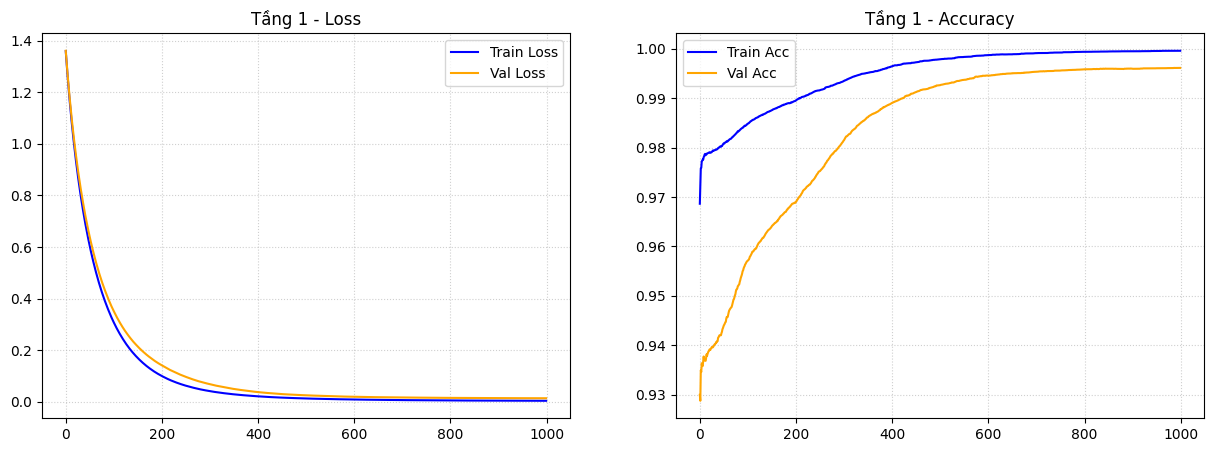

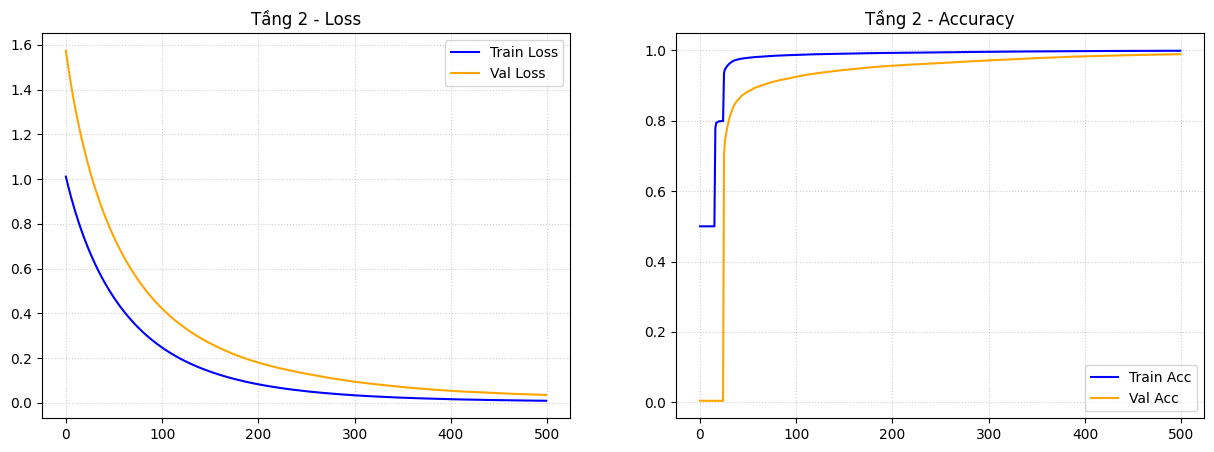


🏆 BÁO CÁO TẦNG 1 (LIGHTGBM)
              precision    recall  f1-score   support

      Benign     0.9988    0.9972    0.9980     90321
       Scen1     1.0000    1.0000    1.0000        35
       Scen2     0.1857    0.3519    0.2431       162
       Scen3     1.0000    0.5556    0.7143         9

    accuracy                         0.9960     90527
   macro avg     0.7961    0.7262    0.7388     90527
weighted avg     0.9973    0.9960    0.9966     90527



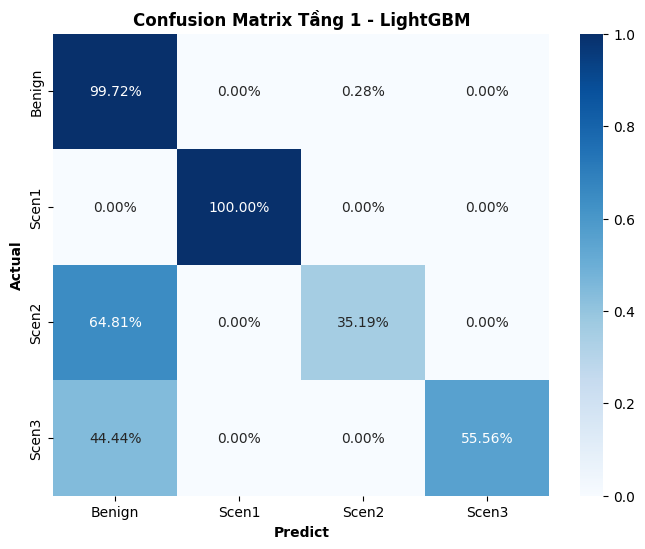


-> [MÀNG LỌC VỚT] Tầng 2 đã soi 90180 mẫu Benign và lôi cổ thêm được:
   + 3621 mẫu Scen2 ẩn mình (Ngưỡng 0.1)!
   + 447 mẫu Scen3 ẩn mình (Ngưỡng 0.03)!

🏆 BÁO CÁO CUỐI CÙNG (LIGHTGBM)
              precision    recall  f1-score   support

      Benign     0.9999    0.9533    0.9761     90321
       Scen1     1.0000    1.0000    1.0000        35
       Scen2     0.0400    0.9691    0.0768       162
       Scen3     0.0199    1.0000    0.0390         9

    accuracy                         0.9534     90527
   macro avg     0.5150    0.9806    0.5230     90527
weighted avg     0.9981    0.9534    0.9744     90527



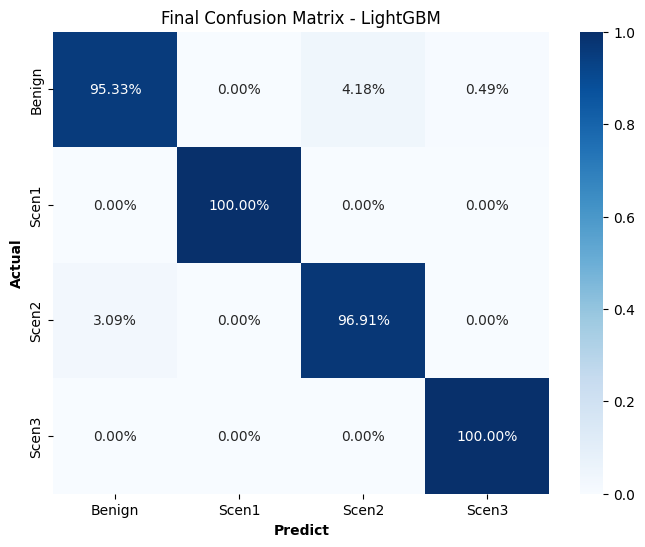

In [1]:
import pandas as pd
import numpy as np
import gc
import lightgbm as lgb
import time
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import os, random, warnings

# 🔒 CỐ ĐỊNH SEED
# def set_all_seeds(seed=42):
#     os.environ['PYTHONHASHSEED'] = str(seed)
#     random.seed(seed)
#     np.random.seed(seed)
#     print(f"🔒 [HỆ THỐNG] Đã khóa SEED = {seed}")

# set_all_seeds(42)
warnings.filterwarnings('ignore')

# ==============================================================================
# 1. LOAD DATA & TIỀN XỬ LÝ
# ==============================================================================
print("\n[1/5] Đang đọc dữ liệu và chia tập Train/Val/Test...")
file_path = '/kaggle/input/datasets/phanthanhhoang/cert-r42-session/session_r4.2.parquet'
df = pd.read_parquet(file_path)
df['insider'] = df['insider'].astype(int)
df = df.sort_values(by=['user', 'starttime']).reset_index(drop=True)

exclude_cols = ['insider', 'starttime', 'endtime', 'sessionid', 'user', 'day', 'week']
feature_cols = [col for col in df.columns if col not in exclude_cols]

def split_user_time_multiclass(df):
    df = df.sort_values(by='starttime').reset_index(drop=True)
    test_idx = int(len(df) * 0.80)
    df_past, df_future = df.iloc[:test_idx], df.iloc[test_idx:]
    known_insiders = set(df_past[df_past['insider'] != 0]['user'])
    df_test = df_future[~df_future['user'].isin(known_insiders)].copy()
    val_idx = int(len(df_past) * 0.80)
    return df_past.iloc[:val_idx], df_past.iloc[val_idx:], df_test

df_train, df_val, df_test = split_user_time_multiclass(df)

# ==============================================================================
# 2. FEATURE ENGINEERING: PHẲNG HÓA WINDOW (THAY THẾ LSTM)
# ==============================================================================
WINDOW_SIZE = 5
def create_tabular_windows(df_subset, window_size=5):
    X_list, y_list = [], []
    for user, group in df_subset.groupby('user'):
        if len(group) < window_size: continue
        feats, labels = group[feature_cols].values, group['insider'].values
        for i in range(len(group) - window_size + 1):
            X_list.append(feats[i : i + window_size].flatten())
            y_list.append(np.max(labels[i : i + window_size]))
    return np.array(X_list), np.array(y_list)

X_train, y_train = create_tabular_windows(df_train, WINDOW_SIZE)
X_val, y_val = create_tabular_windows(df_val, WINDOW_SIZE)
X_test, y_test = create_tabular_windows(df_test, WINDOW_SIZE)

# ==============================================================================
# 3. TẦNG 1: LIGHTGBM MULTI-CLASS (NATIVE API)
# ==============================================================================
print("\n" + "="*50)
print("🟢 TẦNG 1: HUẤN LUYỆN LIGHTGBM (NATIVE API)")
print("="*50)

# Cân bằng dữ liệu
rus = RandomUnderSampler(sampling_strategy={0: 30000}, random_state=42)
X_res, y_res = rus.fit_resample(X_train, y_train)
smote = SMOTE(sampling_strategy={1: 10000, 2: 10000, 3: 10000}, random_state=42, k_neighbors=2)
X_train_bal, y_train_bal = smote.fit_resample(X_res, y_res)

custom_weights = {0: 1, 1: 1.5, 2: 3, 3: 1}
sample_weights_main = np.array([custom_weights[y] for y in y_train_bal])
# Khởi tạo Dataset cho Native API
dtrain_main = lgb.Dataset(X_train_bal, label=y_train_bal, weight=sample_weights_main)
dval_main = lgb.Dataset(X_val, label=y_val, reference=dtrain_main)

# Tham số Tầng 1
params_main = {
    'objective': 'multiclass',
    'num_class': 4,
    'metric': ['auc_mu', 'multi_logloss', 'multi_error'],
    'learning_rate': 0.01,        # 1. Giảm tốc độ học
    'boost_from_average': False,  # Đổi thành False vì đã dùng SMOTE cân bằng dữ liệu
    'num_leaves': 31,             # Tiếp tục hạ từ 64 xuống 31 để ép cây không học vẹt ranh giới SMOTE
    'max_depth': 8,               # Ép nông lại để chỉ học những đặc trưng rành mạch nhất
    'min_data_in_leaf': 200,      # Lá phải đủ lớn để chứa cả mẫu thật lẫn mẫu ảo
    'path_smooth': 1.5,           # Tăng độ mượt để ranh giới ra quyết định bớt sắc lẹm
    'min_gain_to_split': 0.2,     # Đòi hỏi lợi ích (gain) cao hơn mới cho phép chia nhánh
    'lambda_l1': 2.0,             # Tăng phạt L1 để loại bỏ các đặc trưng nhiễu giữa Lớp 1 và 3
    'lambda_l2': 2.0,
    'feature_fraction': 0.7,      
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'random_state': 42,
    'verbosity': -1,
}

evals_result_main = {}
start_time_t1 = time.time()
bst_main = lgb.train(
    params_main,
    dtrain_main,
    num_boost_round=1000,
    valid_sets=[dtrain_main, dval_main],
    valid_names=['training', 'valid_1'],
    callbacks=[
        lgb.early_stopping(100, first_metric_only=True, verbose=False),
        lgb.record_evaluation(evals_result_main)
    ]
)
time_t1 = time.time() - start_time_t1
# ==============================================================================
# 4. TẦNG 2: LIGHTGBM BINARY (VỚT SCEN 2 - NATIVE API)
# ==============================================================================
print("\n" + "="*50)
print("🔵 TẦNG 2: HUẤN LUYỆN SALVAGE NET (NATIVE API)")
print("="*50)

# mask_t2 = (y_train_bal == 0) | (y_train_bal == 2)
# X_train_t2 = X_train_bal[mask_t2]
# y_train_t2 = np.where(y_train_bal[mask_t2] == 2, 1, 0)

# idx_1 = np.where(y_train_t2 == 1)[0]
# idx_0_down = np.random.choice(np.where(y_train_t2 == 0)[0], size=len(idx_1), replace=False)
# idx_bal_t2 = np.concatenate([idx_0_down, idx_1])

# mask_val_t2 = (y_val == 0) | (y_val == 2)
# X_val_t2 = X_val[mask_val_t2]
# y_val_t2 = np.where(y_val[mask_val_t2] == 2, 1, 0)

# dtrain_t2 = lgb.Dataset(X_train_t2[idx_bal_t2], label=y_train_t2[idx_bal_t2])
# dval_t2 = lgb.Dataset(X_val_t2, label=y_val_t2, reference=dtrain_t2)

# params_t2 = {
#     'objective': 'binary',
#     'metric': ['binary_logloss', 'binary_error'],
#     'learning_rate': 0.05,
#     'num_leaves': 64,
#     'max_depth': 10,     
#     'min_data_in_leaf': 10,
#     'lambda_l1': 1.0,
#     'lambda_l2': 1.0,
#     'feature_fraction': 0.5,
#     'bagging_fraction': 0.8,
#     'bagging_freq': 5,
#     'random_state': 42,
#     'verbosity': -1
# }

# 1. Lọc tập dữ liệu: Chỉ lấy Benign (0), Scen 2 (2) và Scen 3 (3)
# Lưu ý: y_train_bal là nhãn gốc [0, 1, 2, 3]
mask_t2 = (y_train_bal == 0) | (y_train_bal == 2) | (y_train_bal == 3)
X_train_t2_raw = X_train_bal[mask_t2]
y_train_t2_raw = y_train_bal[mask_t2]

# 2. Map nhãn về dạng [0, 1, 2] để LightGBM Multiclass chạy (Phải bắt đầu từ 0)
# 0 -> 0 (Benign), 2 -> 1 (Scen 2), 3 -> 2 (Scen 3)
label_map_t2 = {0: 0, 2: 1, 3: 2}
y_train_t2_mapped = np.array([label_map_t2[x] for x in y_train_t2_raw])

# 3. Cân bằng dữ liệu cho Tầng 2 (Ép tỷ lệ để Scen 2 và 3 có tiếng nói)
# Lấy toàn bộ Scen 2 và Scen 3, sau đó lấy một lượng Benign tương ứng
idx_s2 = np.where(y_train_t2_mapped == 1)[0]
idx_s3 = np.where(y_train_t2_mapped == 2)[0]
idx_benign = np.where(y_train_t2_mapped == 0)[0]

# Chọn số lượng Benign bằng tổng Scen 2 + Scen 3 (hoặc tùy chỉnh)
num_samples_to_pick = len(idx_s2) + len(idx_s3)
idx_benign_down = np.random.choice(idx_benign, size=min(len(idx_benign), num_samples_to_pick), replace=False)

idx_bal_t2 = np.concatenate([idx_benign_down, idx_s2, idx_s3])
np.random.shuffle(idx_bal_t2)

# 4. Chuẩn bị tập Validation cho Tầng 2
mask_val_t2 = (y_val == 0) | (y_val == 2) | (y_val == 3)
X_val_t2 = X_val[mask_val_t2]
y_val_t2_mapped = np.array([label_map_t2[x] for x in y_val[mask_val_t2]])

custom_weights_t2 = {0: 1, 1: 5, 2: 3}
sample_weights_full = np.array([custom_weights_t2[y] for y in y_train_t2_mapped])
sample_weights_bal = sample_weights_full[idx_bal_t2]
# 5. Khởi tạo Dataset
dtrain_t2 = lgb.Dataset(X_train_t2_raw[idx_bal_t2], label=y_train_t2_mapped[idx_bal_t2], weight=sample_weights_bal)
dval_t2 = lgb.Dataset(X_val_t2, label=y_val_t2_mapped, reference=dtrain_t2)

# 6. Tham số Tầng 2 (Đa lớp: 3 lớp)
params_t2 = {
    'objective': 'multiclass',
    'num_class': 3,
    'metric': ['multi_logloss', 'multi_error', 'auc_mu'],
    'learning_rate': 0.01,
    'boost_from_average': True,
    'num_leaves': 32,
    'max_depth': 10,     
    'min_data_in_leaf': 40,
    'lambda_l1': 1.0,
    'lambda_l2': 1.0,
    'feature_fraction': 0.7,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'random_state': 42,
    'verbosity': -1
}

evals_result_t2 = {}
start_time_t2 = time.time()
model_expert = lgb.train(
    params_t2,
    dtrain_t2,
    num_boost_round=500,
    valid_sets=[dtrain_t2, dval_t2],
    valid_names=['training', 'valid_1'],
    callbacks=[
        lgb.early_stopping(50, first_metric_only=True, verbose=False),
        lgb.record_evaluation(evals_result_t2)
    ]
)
time_t2 = time.time() - start_time_t2
print(f"🚀 TỔNG THỜI GIAN HUẤN LUYỆN: {int((time_t1+time_t2) // 60)} phút {(time_t1+time_t2) % 60:.2f} giây")

# ==============================================================================
# 5. VẼ BIỂU ĐỒ (Cập nhật lấy từ evals_result)
# ==============================================================================
def plot_native_history(res_dict, title, is_multiclass=True):
    loss_key = 'multi_logloss' if is_multiclass else 'binary_logloss'
    err_key = 'multi_error' if is_multiclass else 'binary_error'
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].plot(res_dict['training'][loss_key], label='Train Loss', color='blue')
    axes[0].plot(res_dict['valid_1'][loss_key], label='Val Loss', color='orange')
    axes[0].set_title(f'{title} - Loss')
    axes[0].legend(); axes[0].grid(True, linestyle=':', alpha=0.6)
    
    axes[1].plot(1 - np.array(res_dict['training'][err_key]), label='Train Acc', color='blue')
    axes[1].plot(1 - np.array(res_dict['valid_1'][err_key]), label='Val Acc', color='orange')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].legend(); axes[1].grid(True, linestyle=':', alpha=0.6)
    plt.show()

plot_native_history(evals_result_main, "Tầng 1", True)
plot_native_history(evals_result_t2, "Tầng 2", True)

# ==============================================================================
# 6. MÀNG LỌC VỚT & KẾT QUẢ CUỐI CÙNG
# ==============================================================================
# Native API: predict trả về xác suất. Với multiclass là mảng (N, num_class)
probs_main = bst_main.predict(X_test)
preds_main = np.argmax(probs_main, axis=1)

classes_names = ['Benign', 'Scen1', 'Scen2', 'Scen3']
print("\n🏆 BÁO CÁO TẦNG 1 (LIGHTGBM)")
print(classification_report(y_test, preds_main, target_names=classes_names, digits=4))
cm = confusion_matrix(y_test, preds_main)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=classes_names, yticklabels=classes_names)
plt.title('Confusion Matrix Tầng 1 - LightGBM', fontweight='bold')
plt.xlabel('Predict', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.show()

final_preds = preds_main.copy()
review_idx = np.where(preds_main == 0)[0]

# if len(review_idx) > 0:
#     # Với binary: predict trả về mảng 1D xác suất lớp 1
#     probs_scen2 = bst_expert.predict(X_test[review_idx])
#     is_scen2 = probs_scen2 >= 0.25 
#     final_preds[review_idx[is_scen2]] = 2

if len(review_idx) > 0:
    # probs_expert có shape (N, 3): Cột 0(Benign), Cột 1(Scen2), Cột 2(Scen3)
    probs_expert = model_expert.predict(X_test[review_idx], verbose=0)
    # 🔴 ĐẶT NGƯỠNG VỚT ĐỘC LẬP CHO TỪNG KỊCH BẢN
    THRESHOLD_SCEN2 = 0.1  # Scen 2 đông hơn, để ngưỡng cao một chút cho đỡ vớt nhầm rác
    THRESHOLD_SCEN3 = 0.03  # Scen 3 quá hiếm, hạ lưới sát đáy biển để vét
    new_preds = np.zeros(len(review_idx), dtype=int)
    for i in range(len(probs_expert)):
        prob_scen2 = probs_expert[i, 1]
        prob_scen3 = probs_expert[i, 2]
        # Kiểm tra xem thằng nào qua vòng gửi xe
        pass_s2 = prob_scen2 >= THRESHOLD_SCEN2
        pass_s3 = prob_scen3 >= THRESHOLD_SCEN3
        # KỊCH BẢN A: Cả 2 đều vượt ngưỡng -> So găng xem xác suất thằng nào lớn hơn
        if pass_s2 and pass_s3:
            if prob_scen2 > prob_scen3:
                new_preds[i] = 2 
            else:
                new_preds[i] = 3
        # KỊCH BẢN B: Chỉ có Scen 2 vượt ngưỡng
        elif pass_s2:
            new_preds[i] = 2
        # KỊCH BẢN C: Chỉ có Scen 3 vượt ngưỡng
        elif pass_s3:
            new_preds[i] = 3
    # Cập nhật đè lên mảng final
    mask_update = new_preds > 0
    indices_to_update = review_idx[mask_update]
    final_preds[indices_to_update] = new_preds[mask_update]
    print(f"\n-> [MÀNG LỌC VỚT] Tầng 2 đã soi {len(review_idx)} mẫu Benign và lôi cổ thêm được:")
    print(f"   + {np.sum(new_preds == 2)} mẫu Scen2 ẩn mình (Ngưỡng {THRESHOLD_SCEN2})!")
    print(f"   + {np.sum(new_preds == 3)} mẫu Scen3 ẩn mình (Ngưỡng {THRESHOLD_SCEN3})!")

classes_names = ['Benign', 'Scen1', 'Scen2', 'Scen3']
print("\n🏆 BÁO CÁO CUỐI CÙNG (LIGHTGBM)")
print(classification_report(y_test, final_preds, target_names=classes_names, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, final_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=classes_names, yticklabels=classes_names)
plt.title('Final Confusion Matrix - LightGBM')
plt.xlabel('Predict', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.show()

In [2]:
# Tạo danh sách tên đặc trưng cho cửa sổ sliding window
# format: [feature_name]_t-4, [feature_name]_t-3, ... [feature_name]_t-0
flattened_feature_names = []
for i in range(WINDOW_SIZE):
    time_step = WINDOW_SIZE - 1 - i
    for col in feature_cols:
        flattened_feature_names.append(f"{col}_t-{time_step}")

# Kiểm tra độ dài khớp với X_train (phải bằng len(feature_cols) * 5)
print(f"Tổng số đặc trưng sau khi phẳng hóa: {len(flattened_feature_names)}")

Tổng số đặc trưng sau khi phẳng hóa: 605



--- TOP 20 GLOBAL FEATURES (TÊN GỐC GỘP LẠI) ---
                      base_feature    importance
120               usb_mean_usb_dur  1.710504e+06
113                          n_usb  1.275512e+06
3                          ITAdmin  8.619435e+05
91                    http_n_leakf  8.088431e+05
80      http_leakf_mean_http_c_len  6.472877e+05
5                                O  5.865927e+05
86             http_mean_url_depth  5.038336e+05
81   http_leakf_mean_http_c_nwords  4.553611e+05
107          n_concurrent_sessions  2.534655e+05
83         http_leakf_mean_url_len  2.113099e+05
119                           team  1.304297e+05
102                    isafterhour  1.138856e+05
19                          f_unit  1.017090e+05
14                email_mean_n_des  7.300659e+04
110                         n_file  6.726062e+04
82       http_leakf_mean_url_depth  6.275653e+04
8                         duration  5.959679e+04
0                                A  4.232605e+04
105                

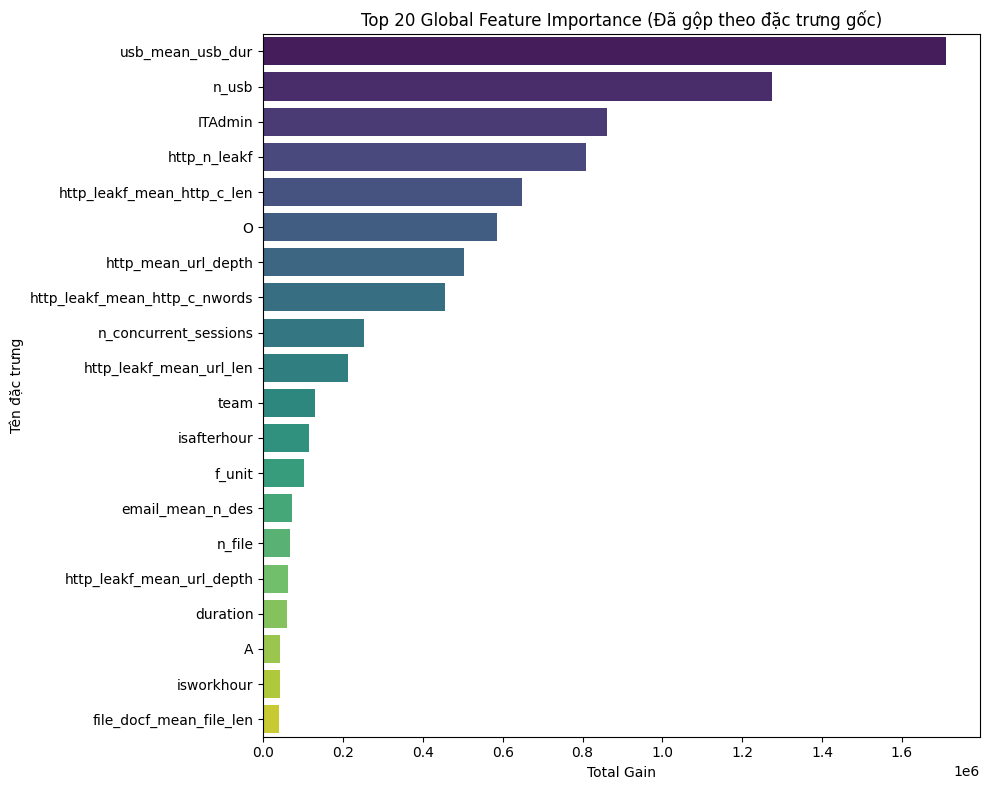

In [5]:
# 1. Lấy tầm quan trọng Global từ mô hình
importance_global = bst_main.feature_importance(importance_type='gain')

df_global = pd.DataFrame({
    'feature_raw': flattened_feature_names,
    'importance': importance_global
})

# 2. Xóa đuôi _t-k để lấy tên gốc (dùng rsplit để cắt từ phải sang trái)
df_global['base_feature'] = df_global['feature_raw'].apply(lambda x: x.rsplit('_t-', 1)[0])

# 3. Gom nhóm theo tên gốc và tính TỔNG độ quan trọng trong cả window
df_global_base = df_global.groupby('base_feature')['importance'].sum().reset_index()
df_global_base = df_global_base.sort_values(by='importance', ascending=False).head(20)

print("\n--- TOP 20 GLOBAL FEATURES (TÊN GỐC GỘP LẠI) ---")
print(df_global_base)

# Vẽ biểu đồ
plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='base_feature', data=df_global_base, palette='viridis')
plt.title('Top 20 Global Feature Importance (Đã gộp theo đặc trưng gốc)')
plt.xlabel('Total Gain')
plt.ylabel('Tên đặc trưng')
plt.tight_layout()
plt.show()


--- BẮT ĐẦU VẼ SHAP CHO TỪNG LỚP ---

--- TOP 20 ĐẶC TRƯNG CHO LỚP: Benign (TÊN GỐC) ---
                        base_feature  importance
120                 usb_mean_usb_dur    1.070698
86               http_mean_url_depth    0.654850
113                            n_usb    0.547153
14                  email_mean_n_des    0.256777
102                      isafterhour    0.213213
2                                  E    0.173553
0                                  A    0.148369
1                                  C    0.147206
7                               dept    0.140330
19                            f_unit    0.137934
115                             role    0.132437
4                                  N    0.120101
107            n_concurrent_sessions    0.115772
8                           duration    0.115329
5                                  O    0.109781
79            http_jobf_mean_url_len    0.074443
106                         n_allact    0.074050
119                         

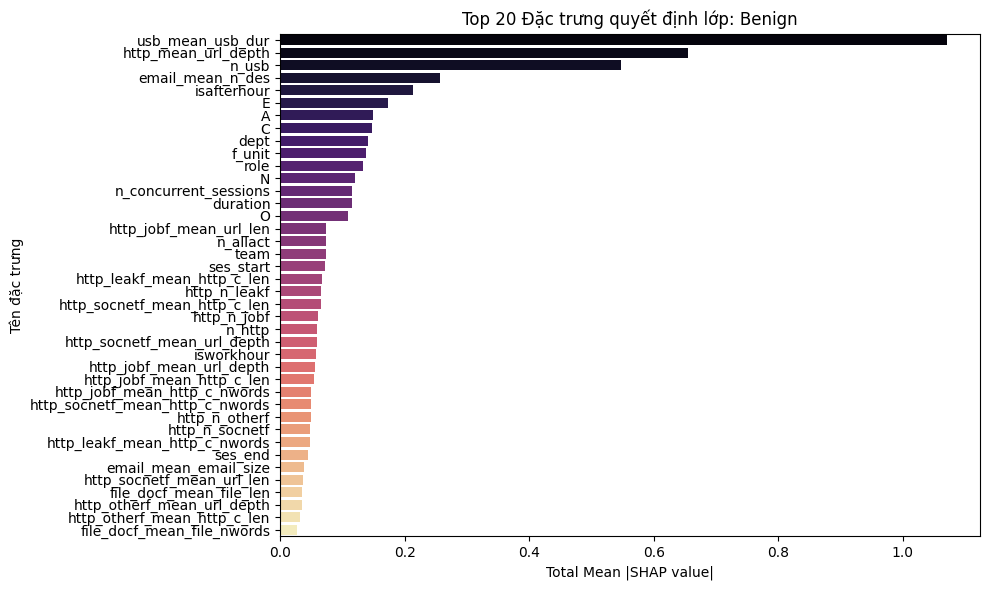


--- TOP 20 ĐẶC TRƯNG CHO LỚP: Scen1 (TÊN GỐC) ---
                      base_feature  importance
91                    http_n_leakf    0.604173
80      http_leakf_mean_http_c_len    0.444351
81   http_leakf_mean_http_c_nwords    0.390254
83         http_leakf_mean_url_len    0.170650
7                             dept    0.167406
113                          n_usb    0.110909
39              file_mean_file_len    0.058970
82       http_leakf_mean_url_depth    0.051386
110                         n_file    0.049003
40           file_mean_file_nwords    0.046738
120               usb_mean_usb_dur    0.035149
100    http_socnetf_mean_url_depth    0.034146
4                                N    0.033197
115                           role    0.025127
5                                O    0.018633
18                        end_with    0.010204
119                           team    0.006654
14                email_mean_n_des    0.005718
111                         n_http    0.004242
8        

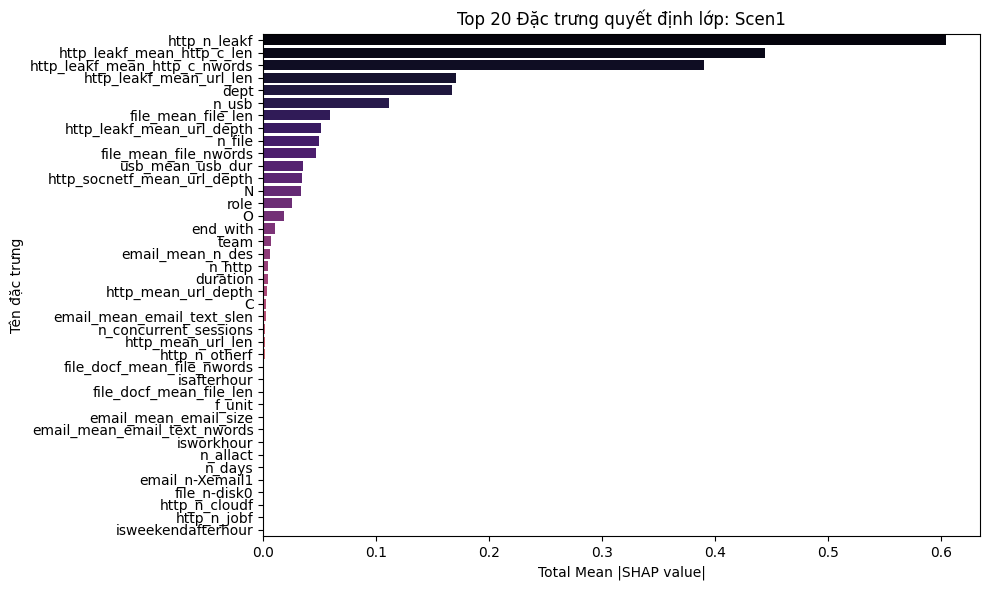


--- TOP 20 ĐẶC TRƯNG CHO LỚP: Scen2 (TÊN GỐC) ---
                     base_feature  importance
120              usb_mean_usb_dur    0.703486
113                         n_usb    0.624215
86            http_mean_url_depth    0.571719
19                         f_unit    0.216763
76      http_jobf_mean_http_c_len    0.166223
29              file_docf_n-disk0    0.161504
1                               C    0.149472
8                        duration    0.134397
5                               O    0.104514
107         n_concurrent_sessions    0.095374
77   http_jobf_mean_http_c_nwords    0.093461
79         http_jobf_mean_url_len    0.092471
78       http_jobf_mean_url_depth    0.089522
45                    file_n_docf    0.084788
105                    isworkhour    0.084622
110                        n_file    0.084113
117                     ses_start    0.080418
115                          role    0.076660
0                               A    0.070952
41                   file_n-d

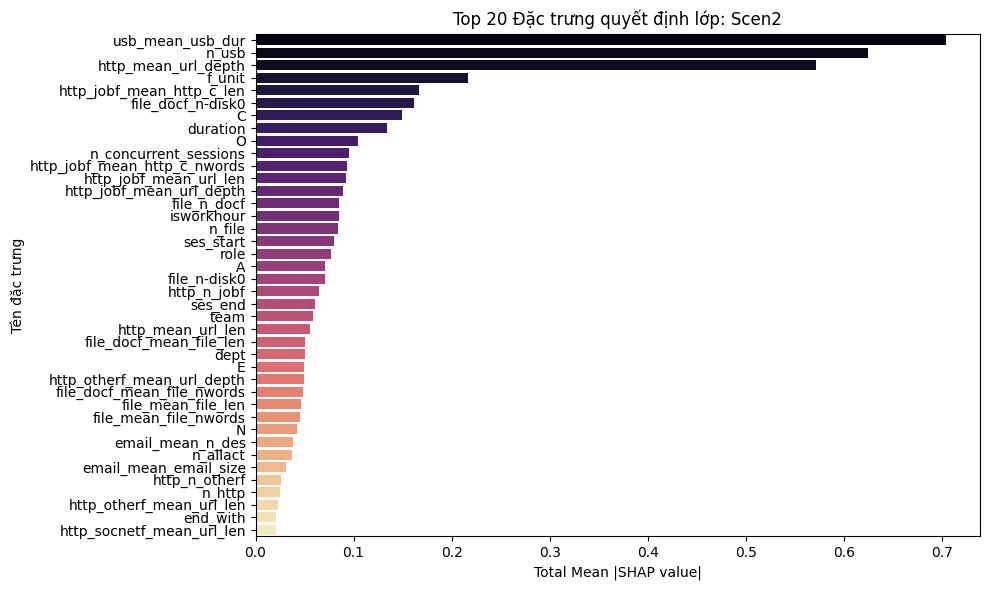


--- TOP 20 ĐẶC TRƯNG CHO LỚP: Scen3 (TÊN GỐC) ---
                        base_feature  importance
3                            ITAdmin    1.628546
107            n_concurrent_sessions    0.828105
119                             team    0.209000
111                           n_http    0.103971
105                       isworkhour    0.103882
5                                  O    0.099197
106                         n_allact    0.087872
117                        ses_start    0.070153
102                      isafterhour    0.070065
116                          ses_end    0.040125
0                                  A    0.035028
92                     http_n_otherf    0.031101
113                            n_usb    0.027940
8                           duration    0.016251
2                                  E    0.015262
120                 usb_mean_usb_dur    0.013398
89                      http_n_hackf    0.012508
72        http_hackf_mean_http_c_len    0.011285
95    http_otherf_

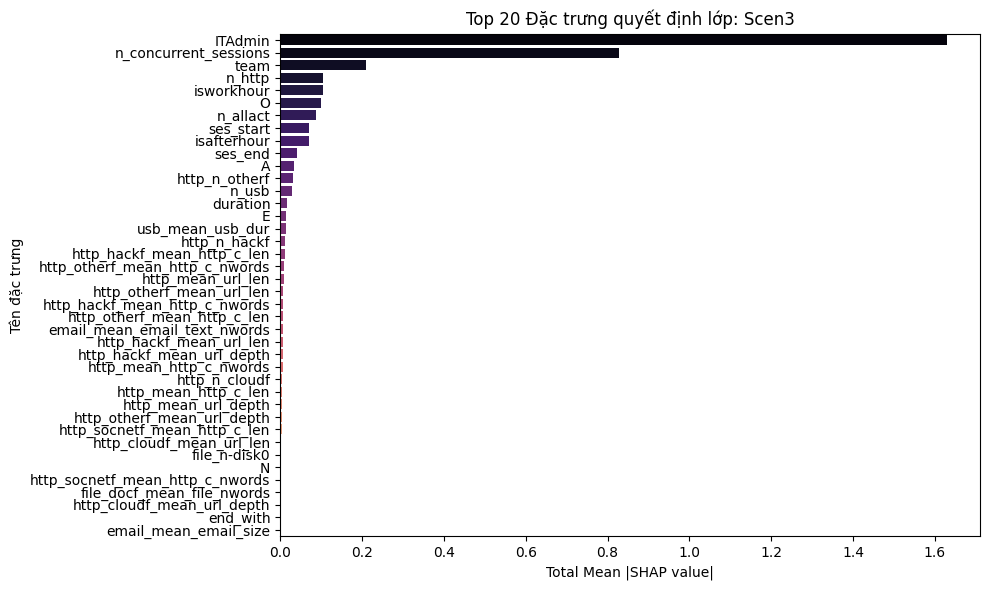

In [9]:
import shap

explainer = shap.TreeExplainer(bst_main)
sample_size = min(1000, X_test.shape[0])
X_test_sample = X_test[:sample_size]
shap_values = explainer.shap_values(X_test_sample)

print("\n--- BẮT ĐẦU VẼ SHAP CHO TỪNG LỚP ---")
for i, class_name in enumerate(classes_names):
    print(f"\n--- TOP 20 ĐẶC TRƯNG CHO LỚP: {class_name} (TÊN GỐC) ---")
    
    # 🔴 BÍ KÍP XỬ LÝ LỖI SHAPE Ở ĐÂY
    if isinstance(shap_values, list):
        # Nếu SHAP trả về dạng List (Bản cũ)
        class_shap = shap_values[i]
    elif isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
        # Nếu SHAP trả về dạng Mảng 3D: (Samples, Features, Classes)
        class_shap = shap_values[:, :, i]
    else:
        # Nếu SHAP trả về dạng Explanation Object (Bản siêu mới)
        class_shap = shap_values.values[:, :, i]

    # Tính trị tuyệt đối trung bình của SHAP values cho lớp i
    vals = np.abs(class_shap).mean(axis=0)
    
    # Khớp dữ liệu vào DataFrame
    df_class = pd.DataFrame({
        'feature_raw': flattened_feature_names,
        'importance': vals
    })
    
    # Xóa đuôi _t-k
    df_class['base_feature'] = df_class['feature_raw'].apply(lambda x: x.rsplit('_t-', 1)[0])
    
    # Gom nhóm theo tên gốc và tính TỔNG tác động SHAP trong cả window
    df_class_base = df_class.groupby('base_feature')['importance'].sum().reset_index()
    df_class_base = df_class_base.sort_values(by='importance', ascending=False).head(40)
    
    print(df_class_base)
    
    # Vẽ biểu đồ
    plt.figure(figsize=(10, 6))
    sns.barplot(x='importance', y='base_feature', data=df_class_base, palette='magma')
    plt.title(f'Top 20 Đặc trưng quyết định lớp: {class_name}')
    plt.xlabel('Total Mean |SHAP value|')
    plt.ylabel('Tên đặc trưng')
    plt.tight_layout()
    plt.show()

In [11]:
# Khởi tạo một 'set' rỗng để chứa các đặc trưng. 
# Ưu điểm của set là tự động loại bỏ mọi phần tử bị trùng lặp.
all_top_features_set = set()

print("\n--- ĐANG GỘP TOP 20 ĐẶC TRƯNG TỪ CÁC LỚP ---")

for i, class_name in enumerate(classes_names):
    # 1. Trích xuất SHAP an toàn (như code đã sửa ở trên)
    if isinstance(shap_values, list):
        class_shap = shap_values[i]
    elif isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
        class_shap = shap_values[:, :, i]
    else:
        class_shap = shap_values.values[:, :, i]

    vals = np.abs(class_shap).mean(axis=0)
    
    # 2. Tạo DataFrame và lấy tên gốc
    df_class = pd.DataFrame({'feature_raw': flattened_feature_names, 'importance': vals})
    df_class['base_feature'] = df_class['feature_raw'].apply(lambda x: x.rsplit('_t-', 1)[0])
    df_class_base = df_class.groupby('base_feature')['importance'].sum().reset_index()
    
    # 3. Lấy ra TÊN của 20 đặc trưng đứng đầu lớp này dưới dạng mảng (list)
    top_20_class_features = df_class_base.sort_values(by='importance', ascending=False).head(40)['base_feature'].tolist()
    
    # 4. Đưa mảng này vào set chung (Hàm update() của set sẽ tự nạp thêm phần tử mới và tự động loại bỏ trùng lặp)
    all_top_features_set.update(top_20_class_features)

# Ép ngược set về lại list (mảng) để dễ thao tác sau này
final_unique_features = list(all_top_features_set)

# ==========================================
# IN KẾT QUẢ
# ==========================================
print(f"\n✅ ĐÃ GỘP XONG! Tổng số đặc trưng duy nhất thu được: {len(final_unique_features)} đặc trưng.")
print("="*60)
print("Mảng đặc trưng không trùng lặp (final_unique_features):")
print(final_unique_features)

# (Tùy chọn) Lưu ra file text nếu cần copy cho nhanh
# with open('selected_features.txt', 'w') as f:
#     for item in final_unique_features:
#         f.write(f"'{item}',\n")


--- ĐANG GỘP TOP 20 ĐẶC TRƯNG TỪ CÁC LỚP ---

✅ ĐÃ GỘP XONG! Tổng số đặc trưng duy nhất thu được: 68 đặc trưng.
Mảng đặc trưng không trùng lặp (final_unique_features):
['http_mean_http_c_len', 'http_n_cloudf', 'http_socnetf_mean_url_depth', 'file_mean_file_len', 'http_cloudf_mean_url_len', 'http_jobf_mean_url_len', 'n_usb', 'http_n_leakf', 'file_n_docf', 'isafterhour', 'n_concurrent_sessions', 'http_leakf_mean_http_c_nwords', 'http_otherf_mean_url_len', 'http_otherf_mean_http_c_nwords', 'http_mean_http_c_nwords', 'http_socnetf_mean_url_len', 'usb_mean_usb_dur', 'role', 'n_allact', 'ses_start', 'http_socnetf_mean_http_c_len', 'email_n-Xemail1', 'http_otherf_mean_http_c_len', 'http_n_jobf', 'http_leakf_mean_http_c_len', 'f_unit', 'http_jobf_mean_url_depth', 'http_n_otherf', 'http_leakf_mean_url_depth', 'email_mean_n_des', 'isweekendafterhour', 'file_docf_n-disk0', 'n_file', 'http_hackf_mean_url_depth', 'n_http', 'http_jobf_mean_http_c_nwords', 'email_mean_email_text_nwords', 'duration',